# Frozen-model expression-imputation benchmarks

This notebook is the publication-facing record comparing our frozen 45.6M RNA-seq model with BulkFormer-50M and BulkFormer-147M on the same fixed 1,000 TCGA primary tumors. The shared-vocabulary analysis is primary; the native-vocabulary analysis is complementary. No model is fine-tuned.

## 1. Protocol

For each benchmark, 15%, 30%, 50%, 70%, 90%, and 100% of evaluable genes are masked under ten deterministic seeds in the final run. Metrics are computed only at masked positions. Shared-vocabulary masks are identical across models for each sample, ratio, and seed. Gene-wise mean and median baselines are frozen from independent ARCHS4 training samples and never use TCGA evaluation expression. Results report the mean and standard deviation across completed masking seeds.

All checkpoints use their intended natural `log1p(TPM)` representation. Gene-length resources differ between model families; therefore MSE is native-target-space specific, while Pearson and Spearman provide the cleaner cross-model comparison.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_benchmark(start):
    for parent in (start.resolve(), *start.resolve().parents):
        if parent.name == 'tcga_imputation' and (parent / 'config.json').is_file():
            return parent
        candidate = parent / 'benchmarks/tcga_imputation'
        if (candidate / 'config.json').is_file():
            return candidate
    raise FileNotFoundError('Start Jupyter from the repository or one of its subdirectories.')

HERE = find_benchmark(Path.cwd())
WORK, RESULTS = HERE / 'work', HERE / 'results'
config = json.loads((HERE / 'config.json').read_text())
manifest = json.loads((RESULTS / 'preparation_manifest.json').read_text())
validation = json.loads((RESULTS / 'one_sample_validation.json').read_text())
samples = pd.read_parquet(RESULTS / 'selected_tcga_samples.parquet')
shared_genes = pd.read_csv(RESULTS / 'shared_genes.csv')
summary_path = RESULTS / 'summary_results.parquet'
per_seed_path = RESULTS / 'per_seed_results.parquet'
per_sample_path = RESULTS / 'per_sample_results.parquet'
archs4_summary_path = RESULTS / 'archs4_holdout_summary_results.parquet'
archs4_per_seed_path = RESULTS / 'archs4_holdout_per_seed_results.parquet'
print(f"Samples: {len(samples):,}; shared evaluable genes: {len(shared_genes):,}; validation: {validation['status']}")

Samples: 1,000; shared evaluable genes: 15,101; validation: passed


## 2. Fixed cohort and gene vocabularies

In [2]:
display(pd.Series({
    'TCGA samples': manifest['samples'],
    'Selection population': manifest['selection_population'],
    'Our native genes': manifest['our_native_genes'],
    'BulkFormer native genes': manifest['bulkformer_native_genes'],
    'Model-vocabulary intersection': manifest['model_vocab_intersection'],
    'Shared evaluable genes': manifest['shared_evaluable_genes'],
}).to_frame('value'))
display(samples.cancer_type.value_counts().head(15).rename_axis('TCGA cancer type').to_frame('samples'))

,value
TCGA samples,1000
Selection population,TCGA Primary Tumor
Our native genes,15165
BulkFormer native genes,20010
Model-vocabulary intersection,15163
Shared evaluable genes,15101


,samples
TCGA cancer type,
Breast Invasive Carcinoma,118
Uterine Corpus Endometrial Carcinoma,63
Lung Adenocarcinoma,58
Lung Squamous Cell Carcinoma,56
Thyroid Carcinoma,55
Kidney Renal Clear Cell Carcinoma,54
Brain Lower Grade Glioma,53
Prostate Adenocarcinoma,48
Head and Neck Squamous Cell Carcinoma,46


## 3. One-sample end-to-end validation gate

In [3]:
gate_rows = []
for benchmark, details in validation['benchmarks'].items():
    for model, values in details['models'].items():
        gate_rows.append({'benchmark': benchmark, 'model': model, **values})
gate = pd.DataFrame(gate_rows)
display(gate[['benchmark', 'model', 'input_shape', 'output_shape', 'masked_native_positions',
              'pearson', 'spearman', 'mse', 'finite_output']])

,benchmark,model,input_shape,output_shape,masked_native_positions,pearson,spearman,mse,finite_output
0,shared_vocab,ours_45.6m,"[1, 15165]","[1, 15165]",2265,0.952704,0.949775,0.282993,True
1,shared_vocab,bulkformer_50m,"[1, 20010]","[1, 20010]",2265,0.897485,0.890998,0.558059,True
2,shared_vocab,bulkformer_147m,"[1, 20010]","[1, 20010]",2265,0.925518,0.920096,0.409466,True
3,native_vocab,ours_45.6m,"[1, 15165]","[1, 15165]",2266,0.955572,0.952931,0.265647,True
4,native_vocab,bulkformer_50m,"[1, 20010]","[1, 20010]",2842,0.895075,0.884049,0.606819,True
5,native_vocab,bulkformer_147m,"[1, 20010]","[1, 20010]",2842,0.929381,0.921341,0.402912,True


## 4. Primary results

The `seeds` column reports the number of completed masking seeds for every condition. Single-pass exploratory points are displayed without an SD; the final paper run should contain ten seeds at every mask ratio.

In [4]:
if summary_path.is_file():
    summary = pd.read_parquet(summary_path)
    # Never display legacy baselines estimated from the TCGA evaluation cohort.
    summary = summary[~summary.method.isin(['gene_mean', 'gene_median'])].copy()
    expected_ratios = {0.15, 0.30, 0.50, 0.70, 0.90, 1.00}
    assert expected_ratios.issubset(set(summary.mask_ratio.round(2))), 'Mask-ratio curve is incomplete'
    def estimate(mean, sd, seeds, digits=3):
        return [f'{m:.{digits}f} ± {s:.{digits}f}' if n > 1 else f'{m:.{digits}f} (1 seed)'
                for m, s, n in zip(mean, sd, seeds)]
    paper = summary.copy()
    paper['Pearson'] = estimate(paper.pearson_mean, paper.pearson_sd, paper.seeds)
    paper['Spearman'] = estimate(paper.spearman_mean, paper.spearman_sd, paper.seeds)
    paper['MSE'] = estimate(paper.mse_mean, paper.mse_sd, paper.seeds)
    display(paper[['benchmark', 'mask_ratio', 'method', 'target_space',
                   'evaluated_genes', 'seeds', 'Pearson', 'Spearman', 'MSE']])
else:
    print('Full benchmark results are not present yet. Run pipeline/run_imputation.py --run.')

,benchmark,mask_ratio,method,target_space,evaluated_genes,seeds,Pearson,Spearman,MSE
0,native_vocab,0.15,bulkformer_147m,bulkformer,18949,10,0.908 ± 0.000,0.905 ± 0.000,0.512 ± 0.002
1,native_vocab,0.30,bulkformer_147m,bulkformer,18949,10,0.683 ± 0.002,0.702 ± 0.002,2.154 ± 0.006
2,native_vocab,0.50,bulkformer_147m,bulkformer,18949,10,0.277 ± 0.005,0.329 ± 0.005,2.776 ± 0.001
3,native_vocab,0.70,bulkformer_147m,bulkformer,18949,1,0.016 (1 seed),0.001 (1 seed),2.818 (1 seed)
4,native_vocab,0.90,bulkformer_147m,bulkformer,18949,1,0.007 (1 seed),0.001 (1 seed),2.819 (1 seed)
5,native_vocab,1.00,bulkformer_147m,bulkformer,18949,1,nan (1 seed),nan (1 seed),7.790 (1 seed)
6,native_vocab,0.15,bulkformer_50m,bulkformer,18949,10,0.885 ± 0.000,0.884 ± 0.000,0.650 ± 0.002
7,native_vocab,0.30,bulkformer_50m,bulkformer,18949,10,0.851 ± 0.000,0.853 ± 0.000,1.032 ± 0.005
8,native_vocab,0.50,bulkformer_50m,bulkformer,18949,10,0.311 ± 0.006,0.395 ± 0.007,2.686 ± 0.005
9,native_vocab,0.70,bulkformer_50m,bulkformer,18949,1,0.049 (1 seed),0.016 (1 seed),2.814 (1 seed)


## 5. Complete masking curves

Error bars show SD across masking seeds when multiple seeds are available. At 100% masking, gene-wise mean/median baselines are undefined because no expression values remain from which to estimate them. Consult the preceding table's `seeds` column before interpreting an incompletely replicated point.

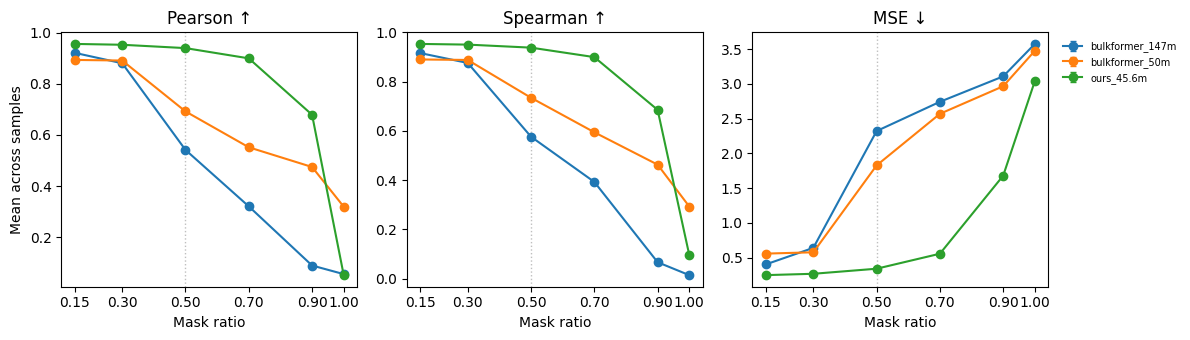

In [5]:
if summary_path.is_file():
    primary = summary[summary.benchmark.eq('shared_vocab')]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for (method, target_space), frame in primary.groupby(['method', 'target_space']):
        frame = frame.sort_values('mask_ratio')
        label = method if not method.startswith('gene_') else f'{method} ({target_space})'
        for ax, metric in zip(axes, ['pearson', 'spearman', 'mse']):
            errors = frame[f'{metric}_sd'].fillna(0)
            ax.errorbar(frame.mask_ratio, frame[f'{metric}_mean'], yerr=errors,
                        marker='o', capsize=2, label=label)
    for ax, title in zip(axes, ['Pearson ↑', 'Spearman ↑', 'MSE ↓']):
        ax.axvline(0.5, color='0.75', linestyle=':', linewidth=1)
        ax.set(xlabel='Mask ratio', title=title, xticks=[0.15, 0.30, 0.50, 0.70, 0.90, 1.00])
    axes[0].set_ylabel('Mean across samples')
    axes[-1].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1))
    fig.tight_layout()

## 6. Our 45.6M model masking curve

This focused view removes comparison-model and baseline lines. Error bars are SD across all completed seeds; single-seed conditions appear without an error bar.

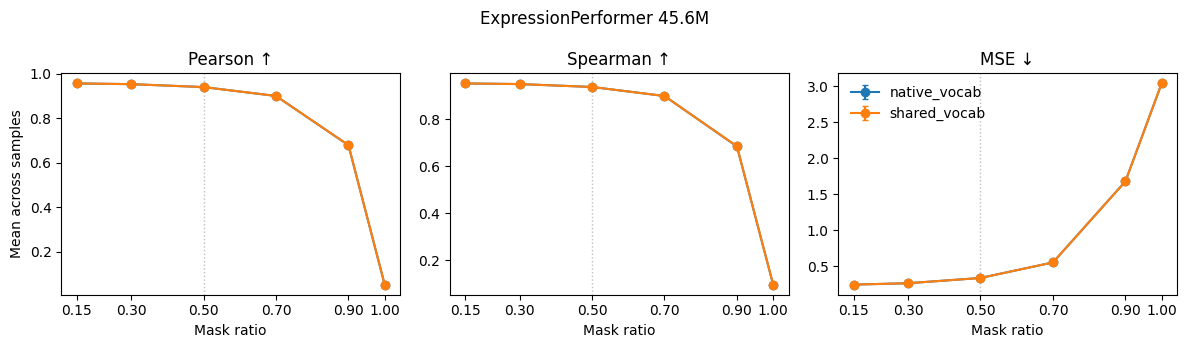

In [6]:
if summary_path.is_file():
    ours_curve = (summary[summary.method.eq('ours_45.6m')]
                  .sort_values(['benchmark', 'mask_ratio']))
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for benchmark, frame in ours_curve.groupby('benchmark'):
        for ax, metric in zip(axes, ['pearson', 'spearman', 'mse']):
            ax.errorbar(frame.mask_ratio, frame[f'{metric}_mean'],
                        yerr=frame[f'{metric}_sd'].fillna(0), marker='o',
                        capsize=2, label=benchmark)
    for ax, title in zip(axes, ['Pearson ↑', 'Spearman ↑', 'MSE ↓']):
        ax.axvline(0.5, color='0.75', linestyle=':', linewidth=1)
        ax.set(xlabel='Mask ratio', title=title,
               xticks=[0.15, 0.30, 0.50, 0.70, 0.90, 1.00])
    axes[0].set_ylabel('Mean across samples')
    axes[-1].legend(frameon=False)
    fig.suptitle('ExpressionPerformer 45.6M')
    fig.tight_layout()

## 7. Our model across TCGA and held-out ARCHS4

This uses the frozen 45.6M model on TCGA human and deterministic 1,000-sample human and mouse subsets from the ARCHS4 `unused` split. Error bars show ±1 SD across ten masking seeds. The SDs are very small relative to the plotted metric ranges, so some bars overlap the markers even with visible caps.

dataset,mask_ratio,pearson_mean,pearson_sd,spearman_mean,spearman_sd,mse_mean,mse_sd,seeds
TCGA human,0.150000,0.955561,0.000113,0.953494,0.000111,0.248565,0.000569,10
TCGA human,0.300000,0.952310,0.000071,0.950736,0.000066,0.267777,0.000453,10
TCGA human,0.500000,0.939201,0.000118,0.938374,0.000075,0.340726,0.000689,10
TCGA human,0.700000,0.899230,0.000125,0.899908,0.000114,0.556196,0.000649,10
TCGA human,0.900000,0.677989,0.000392,0.685067,0.000364,1.681848,0.001479,10
TCGA human,1.000000,0.051717,0.000000,0.095681,0.000000,3.040983,0.000000,10
ARCHS4 holdout human,0.150000,0.954891,0.000127,0.949420,0.000144,0.262982,0.000759,10
ARCHS4 holdout human,0.300000,0.952481,0.000084,0.947029,0.000085,0.277145,0.000506,10
ARCHS4 holdout human,0.500000,0.940701,0.000087,0.934746,0.000082,0.347729,0.000361,10
ARCHS4 holdout human,0.700000,0.899706,0.000145,0.893203,0.000165,0.594021,0.000768,10


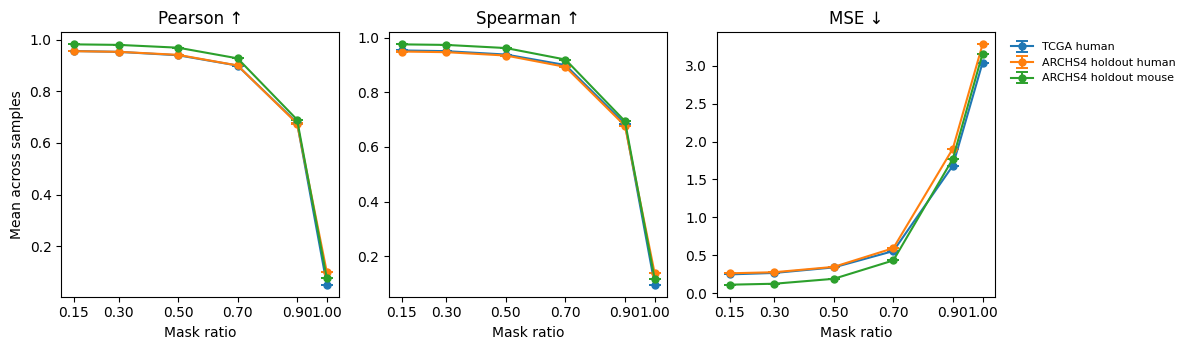

In [7]:
if summary_path.is_file() and archs4_summary_path.is_file():
    tcga_ours = summary[(summary.benchmark.eq('native_vocab')) & summary.method.eq('ours_45.6m')].copy()
    tcga_ours['dataset'] = 'TCGA human'
    columns = ['dataset', 'mask_ratio', 'pearson_mean', 'pearson_sd',
               'spearman_mean', 'spearman_sd', 'mse_mean', 'mse_sd', 'seeds']
    archs4 = pd.read_parquet(archs4_summary_path).copy()
    archs4['dataset'] = archs4.dataset.map({'archs4_holdout_human': 'ARCHS4 holdout human',
                                               'archs4_holdout_mouse': 'ARCHS4 holdout mouse'})
    three_dataset = pd.concat([tcga_ours[columns], archs4[columns]], ignore_index=True)
    metric_columns = [c for c in three_dataset if c.endswith(('_mean', '_sd'))]
    display(three_dataset.style.format({c: '{:.6f}' for c in metric_columns}, na_rep='—').hide(axis='index'))
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for dataset, frame in three_dataset.groupby('dataset', sort=False):
        frame = frame.sort_values('mask_ratio')
        for ax, metric in zip(axes, ['pearson', 'spearman', 'mse']):
            ax.errorbar(frame.mask_ratio, frame[f'{metric}_mean'],
                        yerr=frame[f'{metric}_sd'].fillna(0), fmt='o-', markersize=5,
                        capsize=4, capthick=1.4, elinewidth=1.4, label=dataset)
    for ax, title in zip(axes, ['Pearson ↑', 'Spearman ↑', 'MSE ↓']):
        ax.set(xlabel='Mask ratio', title=title, xticks=[0.15, 0.30, 0.50, 0.70, 0.90, 1.00])
    axes[0].set_ylabel('Mean across samples')
    axes[-1].legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1))
    fig.tight_layout()
    fig.savefig(RESULTS / 'tcga_archs4_holdout_masking_curves.png', dpi=300, bbox_inches='tight')
else:
    print('ARCHS4 holdout results are not present yet; run pipeline/run_archs4_holdout.py.')

## 8. Per-sample behavior

In [8]:
if per_sample_path.is_file():
    per_sample = pd.read_parquet(per_sample_path)
    display(per_sample.groupby(['benchmark', 'method', 'mask_ratio'])
            .agg(samples=('sample_id', 'nunique'), median_pearson=('pearson', 'median'),
                 q10_pearson=('pearson', lambda x: x.quantile(.10)),
                 median_mse=('mse', 'median')).reset_index())

,benchmark,method,mask_ratio,samples,median_pearson,q10_pearson,median_mse
0,native_vocab,bulkformer_147m,0.15,1000,0.912420,8.852988e-01,0.494634
1,native_vocab,bulkformer_147m,0.30,1000,0.693289,5.873872e-01,2.163933
2,native_vocab,bulkformer_147m,0.50,1000,0.265236,7.943124e-02,2.805367
3,native_vocab,bulkformer_147m,0.70,1000,0.014903,-4.524826e-03,2.850785
4,native_vocab,bulkformer_147m,0.90,1000,0.006300,-1.504326e-07,2.853397
5,native_vocab,bulkformer_147m,1.00,1000,NaN,NaN,7.974392
6,native_vocab,bulkformer_50m,0.15,1000,0.886999,8.663038e-01,0.644404
7,native_vocab,bulkformer_50m,0.30,1000,0.857071,8.143127e-01,0.990653
8,native_vocab,bulkformer_50m,0.50,1000,0.280791,8.206392e-02,2.717441
9,native_vocab,bulkformer_50m,0.70,1000,0.042262,1.111694e-02,2.846975


## 9. Interpretation checklist

The paper interpretation should prioritize `shared_vocab`, compare frozen models at every masking ratio, and report variability across masking seeds. The native-vocabulary result answers a different question—performance under each model's intended gene space—and should not replace the controlled shared-gene comparison. MSE comparisons must acknowledge native log-TPM target spaces. Conclusions should distinguish reconstruction of held-out expression values from downstream biological utility.